In [19]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments, scale_filter
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

from scipy.signal import windows

import itertools

D = 1

twopi = 2.*np.pi

def SmoothySpec(a,start=None,end=None,width=3):
   b=a.copy()
   if start is None: start = 0
   if end is None: end = len(a)
   for i in range(start,end):
      #b[i+1::][:-1] = 0.25*b[i::][:-2]+0.5*b[i+1::][:-1]+0.25*b[i::][2:]
      b[i+1:-1] = 0.25*b[i:-2] + 0.5*b[i+1:-1] + 0.25*b[i+2:]
   return b



In [20]:

import pandas as pd

f_all = pd.read_pickle('/home/m/Downloads/psp_mag_1s_2018.pkl')

f_all.info()

f_fR = np.array((f_all.B_R - np.nanmean(f_all.B_R))) 
f_fT = np.array((f_all.B_T - np.nanmean(f_all.B_T)))
f_fN = np.array((f_all.B_N - np.nanmean(f_all.B_N)))

N = 60000
L = 1.*np.float64(N)

f_R = f_fR[:N] - np.nanmean(f_fR[:N])
f_T = f_fT[:N] - np.nanmean(f_fT[:N])
f_N = f_fN[:N] - np.nanmean(f_fN[:N])

f_pR = windows.tukey(N, 0.01) * f_R
f_pT = windows.tukey(N, 0.01) * f_T
f_pN = windows.tukey(N, 0.01) * f_N

valid = np.isfinite(f_pR) & np.isfinite(f_pT) & np.isfinite(f_pN)
f_pR[~valid] = 0.
f_pT[~valid] = 0.
f_pN[~valid] = 0.

#N = len(f_pR)
#print(N)

phys_dims = (L,)
grid_dims = (N,)

dx = L/N
dk = twopi/L


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 64801 entries, 2018-11-02 00:01:09 to 2018-11-02 18:01:09
Freq: S
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   B_R     64799 non-null  float64
 1   B_T     64799 non-null  float64
 2   B_N     64799 non-null  float64
dtypes: float64(3)
memory usage: 2.0 MB


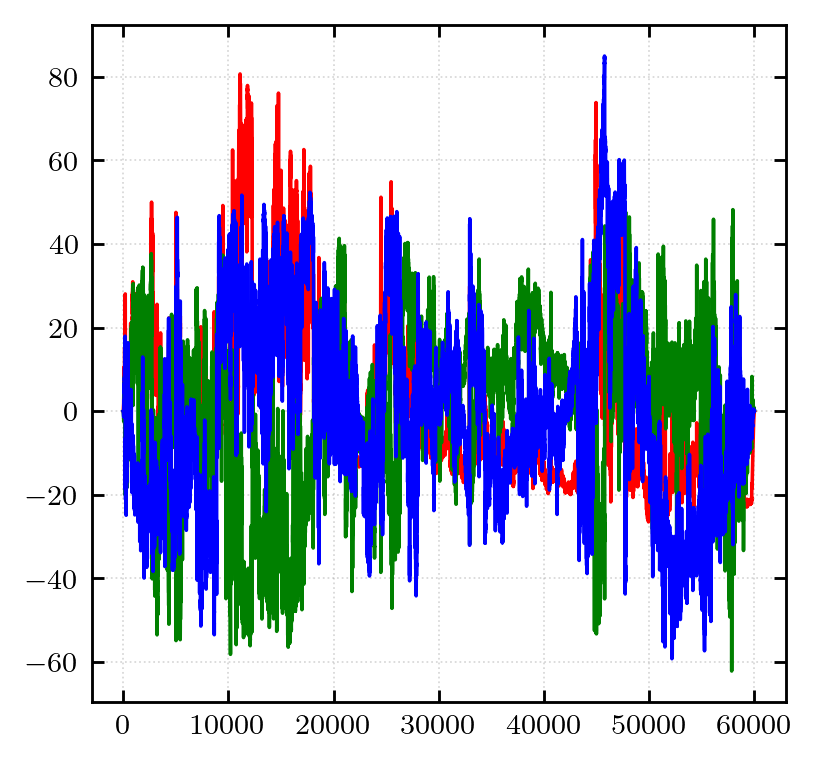

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
ax.plot(np.arange(0, N), f_pR, linewidth=1., color='red')
ax.plot(np.arange(0, N), f_pT, linewidth=1., color='green')
ax.plot(np.arange(0, N), f_pN, linewidth=1., color='blue')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

Text(0.5, 0, 'Frequency, $\\omega$')

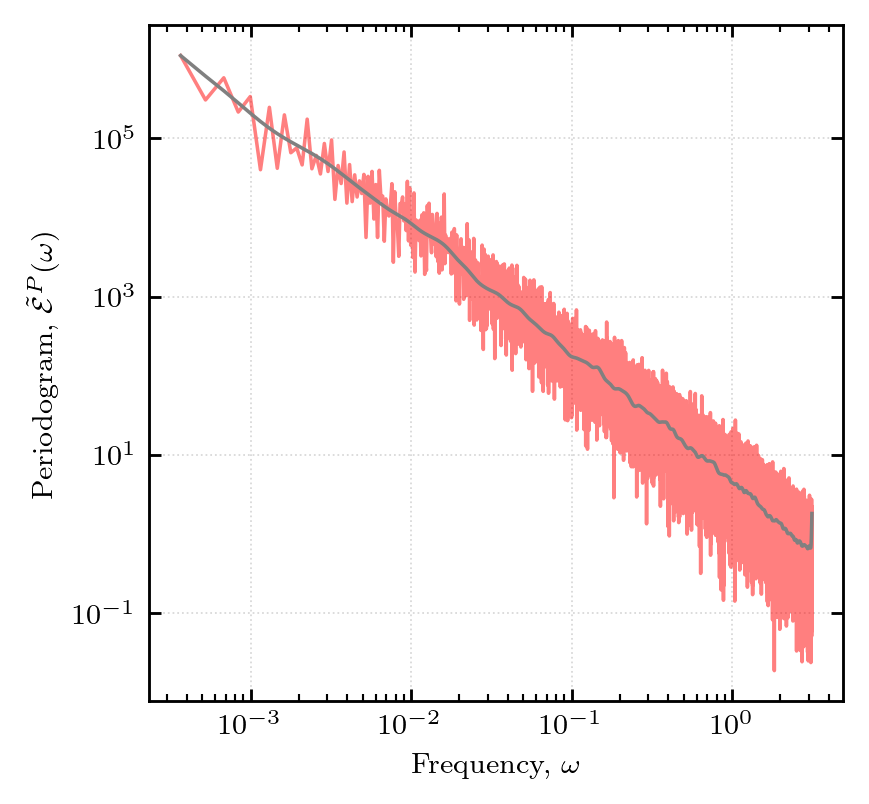

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

# kD_f, fekD_f = per_spectra.modal_spectrum(f_f, phys_dims=phys_dims_f)
# fekD_f = fekD_f * (dk_f/twopi)**D
# k_f, fek_f, _ = spectra_base.spectrum_integrate(kD_f, fekD_f, spec_type='omni', lenn=phys_dims_f, num_bins=N_f//2)
# ax.plot(k_f, fek_f, color='black', linewidth=1.)

#from scipy.signal import periodogram
#k_s, fek_s = periodogram(f_p)
#ax.loglog(k_s, fek_s, color='green', linewidth=1., alpha=0.5)

kD_pR, fekD_pR = per_spectra.modal_spectrum(f_pR, phys_dims=phys_dims)
fekD_pR = fekD_pR * (dk/twopi)**D
k_pR, fek_pR, _ = spectra_base.spectrum_integrate(kD_pR, fekD_pR, spec_type='omni', lenn=phys_dims, num_bins=N//3, min_bin=3.*twopi/L)
#ax.loglog(k_pR, fek_pR, color='red', linewidth=1., linestyle=(0,(5,5)), alpha=0.5)

kD_pT, fekD_pT = per_spectra.modal_spectrum(f_pT, phys_dims=phys_dims)
fekD_pT = fekD_pT * (dk/twopi)**D
k_pT, fek_pT, _ = spectra_base.spectrum_integrate(kD_pT, fekD_pT, spec_type='omni', lenn=phys_dims, num_bins=N//3, min_bin=3.*twopi/L)
#ax.loglog(k_pT, fek_pT, color='green', linewidth=1., linestyle=(0,(5,5)), alpha=0.5)

kD_pN, fekD_pN = per_spectra.modal_spectrum(f_pN, phys_dims=phys_dims)
fekD_pN = fekD_pN * (dk/twopi)**D
k_pN, fek_pN, _ = spectra_base.spectrum_integrate(kD_pN, fekD_pN, spec_type='omni', lenn=phys_dims, num_bins=N//3, min_bin=3.*twopi/L)
#ax.loglog(k_pN, fek_pN, color='blue', linewidth=1., linestyle=(0,(5,5)), alpha=0.5)


k_p, fek_p = k_pR, (fek_pR + fek_pT + fek_pN)
ax.loglog(k_p, fek_p, linewidth=1., color='red', alpha=0.5)

fek_ps = np.exp(SmoothySpec(np.log(fek_p)))
for _ in range(2):
    fek_ps = np.exp(SmoothySpec(np.log(fek_ps)))
ax.loglog(k_p, fek_ps, linewidth=1., color='gray')

# kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
# fekD = fekD * (dk/twopi)**D
# k, fek, _ = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims, num_bins=N//2)
# ax.loglog(k, fek, color='blue', linewidth=1., alpha=0.5)

# ax.axvline(BREAK, linewidth=1., color='gray', linestyle=(0,(5,5)))

#ax.set_ylim((1e-11, 1e1))
ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'Periodogram, $\tilde{\mathcal{E}}^P(\omega)$')
ax.set_xlabel(r'Frequency, $\omega$')


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


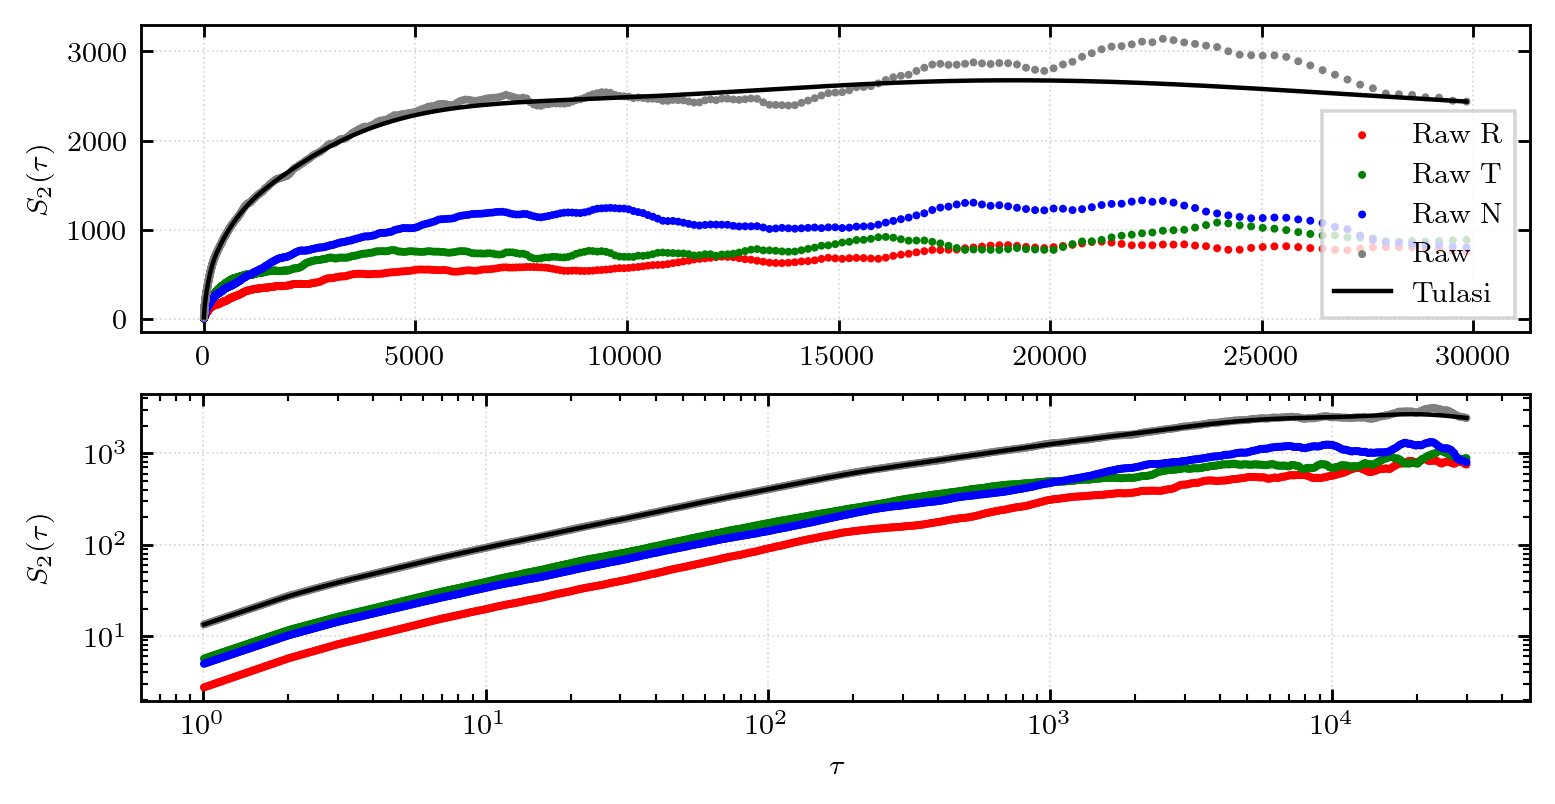

In [23]:

fig, ax = plt.subplots(2, 1, figsize=(3.5*2., 3.5), dpi=256)

lv_pR = statfunc_base.get_all_lagvecs([n+1 for n in grid_dims])
sf_pR = strfn.process_lags(f_pR, f_pR, lv_pR, lenn=phys_dims, shape=[n+1 for n in grid_dims], orders=[2], periodic=True)[0]
lvm_pR = statfunc_base.get_lagvec_magnitude_array([n+1 for n in grid_dims]) * dx
l_pR, sf2_pR, w_pR = statistics_base.bin_data(lvm_pR, sf_pR, bin_func=np.nanmean, cut_excess=True, nan_small=False,
                                           min_bin=dx, max_bin=L/2., bin_loc='center', log_space=True, num_bins=N//64)

lv_pT = statfunc_base.get_all_lagvecs([n+1 for n in grid_dims])
sf_pT = strfn.process_lags(f_pT, f_pT, lv_pT, lenn=phys_dims, shape=[n+1 for n in grid_dims], orders=[2], periodic=True)[0]
lvm_pT = statfunc_base.get_lagvec_magnitude_array([n+1 for n in grid_dims]) * dx
l_pT, sf2_pT, w_pT = statistics_base.bin_data(lvm_pT, sf_pT, bin_func=np.nanmean, cut_excess=True, nan_small=False,
                                           min_bin=dx, max_bin=L/2., bin_loc='center', log_space=True, num_bins=N//64)

lv_pN = statfunc_base.get_all_lagvecs([n+1 for n in grid_dims])
sf_pN = strfn.process_lags(f_pN, f_pN, lv_pN, lenn=phys_dims, shape=[n+1 for n in grid_dims], orders=[2], periodic=True)[0]
lvm_pN = statfunc_base.get_lagvec_magnitude_array([n+1 for n in grid_dims]) * dx
l_pN, sf2_pN, w_pN = statistics_base.bin_data(lvm_pN, sf_pN, bin_func=np.nanmean, cut_excess=True, nan_small=False,
                                           min_bin=dx, max_bin=L/2., bin_loc='center', log_space=True, num_bins=N//64)

l_prR = l_pR[np.isfinite(sf2_pR)]
l_prT = l_pT[np.isfinite(sf2_pT)]
l_prN = l_pN[np.isfinite(sf2_pN)]
sf2_prR = sf2_pR[np.isfinite(sf2_pR)]
sf2_prT = sf2_pT[np.isfinite(sf2_pT)]
sf2_prN = sf2_pN[np.isfinite(sf2_pN)]

sf2_piR = strfn_spectra.interpolate(l_prR, sf2_prR, l_pR)
sf2_piT = strfn_spectra.interpolate(l_prT, sf2_prT, l_pT)
sf2_piN = strfn_spectra.interpolate(l_prN, sf2_prN, l_pN)

for axx in ax:
    axx.scatter(l_pR, sf2_piR, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='none', label='Raw R')
for axx in ax:
    axx.scatter(l_pR, sf2_piT, marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='none', label='Raw T')
for axx in ax:
    axx.scatter(l_pR, sf2_piN, marker='o', s=5., color='blue', zorder=2, linewidth=0.2, edgecolor='none', label='Raw N')

l_p, sf2_pi = l_pR, (sf2_piR + sf2_piT + sf2_piN)
for axx in ax:
  axx.scatter(l_p, sf2_pi, marker='o', s=5., color='gray', zorder=2, linewidth=0.2, edgecolor='none', label='Raw')


sf2_s1 = np.exp(SmoothySpec(np.log(sf2_pi)))
NN = 8
for _i in range(NN):
    sf2_s1 = np.exp(SmoothySpec(np.log(sf2_s1), start=_i*N//NN))
for _ in range(5):
    sf2_s1 = np.exp(SmoothySpec(np.log(sf2_s1), end=12))
#for _ in range(50):
#   sf2_s1 = np.exp(SmoothySpec(np.log(sf2_s1), start=np.min(np.where(l_p > 1./BREAK)[0])))
for axx in ax:
    axx.plot(l_p, sf2_s1, color='black', linewidth=1.25, linestyle='-', label='Tulasi')

# for axx in ax:
#     axx.axvline(1./BREAK, linewidth=1., color='gray', linestyle='--')

for axx in ax:
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    axx.set_ylabel(r'$S_2(\tau)$')
    axx.set_xlabel(r'$\tau$')

ax[0].legend(fancybox=False)
ax[1].set_yscale('log')
ax[1].set_xscale('log')

fig.align_ylabels()


/tmp/ipykernel_65279/1886951406.py:23: RuntimeWarning: invalid value encountered in log
  est_alpha = np.gradient(np.log(sfek_p), np.log(lk_p))


2*b**(beta - 1)*gamma(D/2)*gamma(3/2 - beta/2)/(2**beta*gamma(D/2 + beta/2 - 1/2))

2*2**(beta/2 - 1/2)*sqrt(pi)*gamma(3/2 - beta/2)/(2**beta*gamma(beta/2))

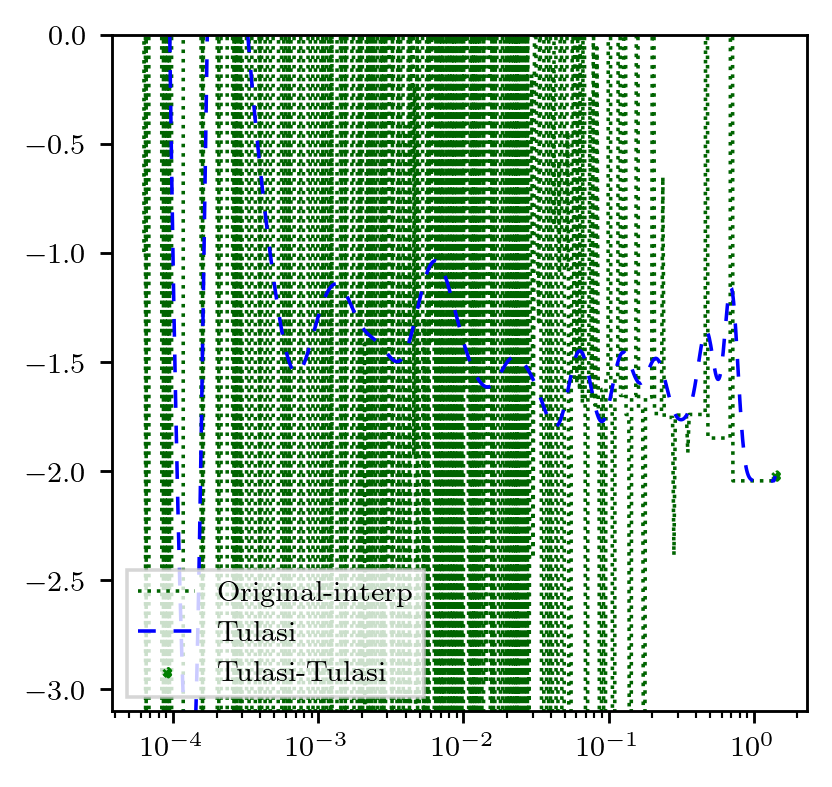

In [28]:

def omni_spectrum(ell, sf2, phys_dims, grid_dims, a=np.sqrt(2.), b=np.sqrt(2.)):

    _dx = phys_dims[0]/grid_dims[0]
    _dk = 2.*np.pi/phys_dims[0]

    dS = np.gradient(sf2, _dx)
    dell = np.gradient(ell, _dx)

    fek = (ell)**2 * (dS/dell) * (1. / 2.) / a
    kk = b / ell

    return kk[::-1], fek[::-1]

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

lk_o, sfek_o = omni_spectrum(l_p, sf2_pi, phys_dims, grid_dims)

smooth_specs = [sf2_pi, sf2_s1]
e_specs = []
e_alphas = []
for sp in smooth_specs:
    lk_p, sfek_p = omni_spectrum(l_p, sp, phys_dims, grid_dims)
    est_alpha = np.gradient(np.log(sfek_p), np.log(lk_p))
    #est_alpha = (lk_p / sfek_p) * np.gradient(sp, lk_p)
    e_specs.append((lk_p, sfek_p))
    e_alphas.append((est_alpha))

ax.plot(e_specs[0][0], e_alphas[0], linewidth=1., linestyle=':', color='darkgreen', label='Original-interp')
ax.plot(e_specs[1][0], e_alphas[1], linewidth=1., linestyle=(0,(5,5)), color='blue', label='Tulasi')

e_alphas12 = SmoothySpec(e_alphas[1])
for _ in range(25):
    e_alphas12 = SmoothySpec(e_alphas12)
ax.scatter(e_specs[1][0], e_alphas12, linewidth=1., linestyle=(0,(5,5)), color='green', label='Tulasi-Tulasi', s=5., marker='X')


import sympy as sp

sp_beta = sp.symbols('beta', positive=True, real=True)
sp_D = sp.symbols('D', positive=True, real=True)
sp_b = sp.symbols('b', positive=True, real=True)
spec_bias = sp.S(2)*sp.S(2)**(-sp_beta) * sp_b**(sp_beta - sp.S(1)) * (sp.gamma(sp_D/sp.S(2)) * sp.gamma((sp.S(3) - sp_beta) / sp.S(2))/sp.gamma(sp_D/sp.S(2) + sp_beta/sp.S(2) - sp.Rational(1,2)))
display(spec_bias.simplify())
spec_bias = spec_bias.subs({sp_D: D, sp_b: sp.sqrt(sp.S(2))})
display(spec_bias)

bias_factor = []
for _a in e_alphas[1]:
    est_alpha[est_alpha > -1.1] = -1.1
    est_alpha[est_alpha < -2.9] = -2.9
    bias_factor.append(np.float64(spec_bias.subs({sp_beta: -_a}).evalf()))
bias_factor = np.array(bias_factor)

ax.set_xscale('log')
ax.set_ylim((-3.1, 0.))

ax.legend(fancybox=False, loc='lower left')


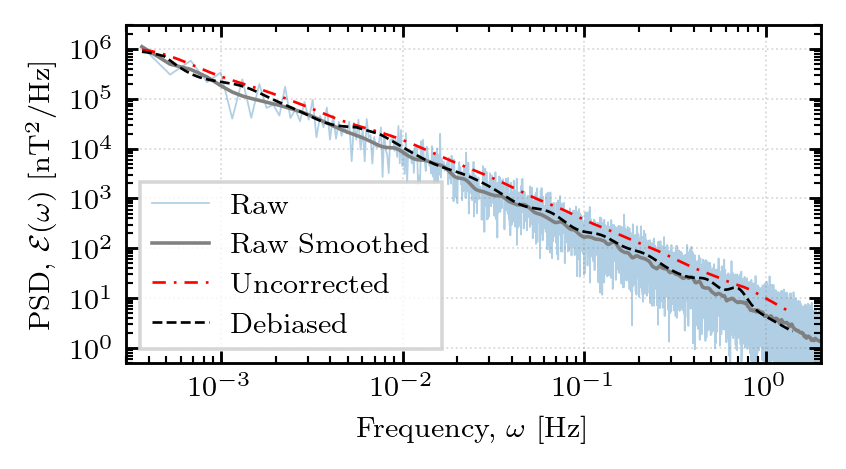

In [29]:

#fig = plt.figure(1, dpi=256, figsize=(3.5, 3.5))
#gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[3, 1], figure=fig, hspace=0., wspace=0.05)

fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))

#ax = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

kmin = np.nanmin(k_p)
sfek_pr = sfek_p[lk_p >= kmin]
bias_factorr = bias_factor[lk_p >= kmin]
lk_pr = lk_p[lk_p >= kmin]

ax.loglog(k_p, fek_p, linewidth=0.5, alpha=0.35, zorder=0, label='Raw')
fekss = np.exp(SmoothySpec(np.log(fek_p)))
for _ in range(25):
    fekss = np.exp(SmoothySpec(np.log(fek_p)))
ax.loglog(k_p, fekss, linewidth=1., zorder=1, label='Raw Smoothed', color='gray')


ax.loglog(lk_pr, sfek_pr, linewidth=0.75, linestyle=(0,(5,3,1,3)), color='red', zorder=3, label=r'Uncorrected')#$\tilde{\mathcal{E}}^S_1(\omega)$
ax.loglog(lk_pr, sfek_pr/bias_factorr, linewidth=0.75, linestyle='--', color='black', zorder=4, label=r'Debiased')#label=r'$\tilde{\mathcal{E}}^S_1(\omega)/B(\tilde{\beta}(\omega))$')

#ksame = k_f[k_f <= np.max(lk_pr)]
#ssame = fek_f[k_f <= np.max(lk_pr)]

#kbad = k[k <= np.max(lk_pr)]
#sbad = fek[k <= np.max(lk_pr)]

#good_spec = strfn_spectra.interpolate(k_f, fek_f, k)
#i_spec = strfn_spectra.interpolate(lk_pr, sfek_pr, ksame)
#b_spec = strfn_spectra.interpolate(lk_pr, sfek_pr/bias_factorr, ksame)

#ax[1].loglog(k, fek/good_spec, linewidth=0.5, alpha=0.5, zorder=0, label='Non-periodic Subset')
#ax[1].loglog(ksame, i_spec/ssame, linewidth=0.75, linestyle=(0,(5,3,1,3)), color='red', zorder=2, label=r'$\tilde{\mathcal{E}}^S_1(\omega)$')
#ax[1].loglog(ksame, b_spec/ssame, linewidth=0.75, linestyle=(0,(5,5)), color='blue', zorder=3, label=r'$\tilde{\mathcal{E}}^S_1(\omega)/B(\tilde{\beta}(\omega))$')


def MAPE(At, Ft):
    return np.nanmean(np.abs((At - Ft)/At))
props = dict(boxstyle='Square', edgecolor='none', linewidth=1., facecolor='none', alpha=0.2)
#ax[0].text(1e2, 0.9, r'MAPE=%s' % MAPE(ssame, i_spec).round(decimals=3), color='red', transform=ax[0].get_xaxis_transform(), bbox=props)
#ax[0].text(1e2, 0.825, r'MAPE=%s' % MAPE(ssame, b_spec).round(decimals=3), color='blue', transform=ax[0].get_xaxis_transform(), bbox=props)


#ax[0].set_ylim((1e-6, 2e0))

for axx in [ax]:
    #axx.axvline(BREAK, color='black', linestyle=(0,(5,5)), linewidth=0.5, zorder=1)
    axx.set_yscale('log')
    axx.set_xscale('log')
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

#ax.set_xlim(ax.get_xlim())

#ax.set_xticklabels([])

ax.legend(frameon=True, fancybox=False)
#ax.legend(ncol=2, bbox_to_anchor=(1.1, 1.3), fancybox=False, shadow=False, frameon=False)

#ax.set_ylim((2e-1, 5e0))

ax.set_ylim((5e-1, 3e6))
ax.set_xlim((3e-4, 2e0))

locmaj = mpl.ticker.LogLocator(base=10.0, numticks=10)
ax.yaxis.set_major_locator(locmaj)
locmin = mpl.ticker.LogLocator(base=10.0, subs=[i/(10.) for i in range(1,10)], numticks=10)
ax.yaxis.set_minor_locator(locmin)

ax.set_ylabel(r'PSD, $\mathcal{E}(\omega)$ [nT$^2$/Hz]')
#ax.set_ylabel(r'Bias')
ax.set_xlabel(r'Frequency, $\omega$ [Hz]')

fig.align_ylabels()

fig.savefig('plots/SW_example.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/SW_example.png', transparent=True, bbox_inches='tight', pad_inches=0)


In [30]:
## Can we compute bias factor for 2D and 3D
## - This will determine how much we want to talk about debiasing

## >> APJ
## Bare min. number of figures

## MAPE or BIAS or SOMETHING...
## QUANTIFYING DIFFERENCES 

## Geophys
## Oceanography
## Atmospheric
## Space/astro

## Supplementary material


In [31]:
def non_uniform_savgol(x, y, window, polynom):
    """
    Applies a Savitzky-Golay filter to y with non-uniform spacing
    as defined in x

    This is based on https://dsp.stackexchange.com/questions/1676/savitzky-golay-smoothing-filter-for-not-equally-spaced-data
    The borders are interpolated like scipy.signal.savgol_filter would do

    Parameters
    ----------
    x : array_like
        List of floats representing the x values of the data
    y : array_like
        List of floats representing the y values. Must have same length
        as x
    window : int (odd)
        Window length of datapoints. Must be odd and smaller than x
    polynom : int
        The order of polynom used. Must be smaller than the window size

    Returns
    -------
    np.array of float
        The smoothed y values
    """
    if len(x) != len(y):
        raise ValueError('"x" and "y" must be of the same size')

    if len(x) < window:
        raise ValueError('The data size must be larger than the window size')

    if type(window) is not int:
        raise TypeError('"window" must be an integer')

    if window % 2 == 0:
        raise ValueError('The "window" must be an odd integer')

    if type(polynom) is not int:
        raise TypeError('"polynom" must be an integer')

    if polynom >= window:
        raise ValueError('"polynom" must be less than "window"')

    half_window = window // 2
    polynom += 1

    # Initialize variables
    A = np.empty((window, polynom))     # Matrix
    tA = np.empty((polynom, window))    # Transposed matrix
    t = np.empty(window)                # Local x variables
    y_smoothed = np.full(len(y), np.nan)

    # Start smoothing
    for i in range(half_window, len(x) - half_window, 1):
        # Center a window of x values on x[i]
        for j in range(0, window, 1):
            t[j] = x[i + j - half_window] - x[i]

        # Create the initial matrix A and its transposed form tA
        for j in range(0, window, 1):
            r = 1.0
            for k in range(0, polynom, 1):
                A[j, k] = r
                tA[k, j] = r
                r *= t[j]

        # Multiply the two matrices
        tAA = np.matmul(tA, A)

        # Invert the product of the matrices
        tAA = np.linalg.inv(tAA)

        # Calculate the pseudoinverse of the design matrix
        coeffs = np.matmul(tAA, tA)

        # Calculate c0 which is also the y value for y[i]
        y_smoothed[i] = 0
        for j in range(0, window, 1):
            y_smoothed[i] += coeffs[0, j] * y[i + j - half_window]

        # If at the end or beginning, store all coefficients for the polynom
        if i == half_window:
            first_coeffs = np.zeros(polynom)
            for j in range(0, window, 1):
                for k in range(polynom):
                    first_coeffs[k] += coeffs[k, j] * y[j]
        elif i == len(x) - half_window - 1:
            last_coeffs = np.zeros(polynom)
            for j in range(0, window, 1):
                for k in range(polynom):
                    last_coeffs[k] += coeffs[k, j] * y[len(y) - window + j]

    # Interpolate the result at the left border
    for i in range(0, half_window, 1):
        y_smoothed[i] = 0
        x_i = 1
        for j in range(0, polynom, 1):
            y_smoothed[i] += first_coeffs[j] * x_i
            x_i *= x[i] - x[half_window]

    # Interpolate the result at the right border
    for i in range(len(x) - half_window, len(x), 1):
        y_smoothed[i] = 0
        x_i = 1
        for j in range(0, polynom, 1):
            y_smoothed[i] += last_coeffs[j] * x_i
            x_i *= x[i] - x[-half_window - 1]

    return y_smoothed